# Practical Session different visual librairies

**@author : Ilyann Mouisset--Ferrara**

**@group : APP-BDML2-2025034**

**@email : ilyann.mouisset--ferrara@efrei.fr**


Python provides a variety of libraries that offer different features for data visualization. All of these libraries offer different functionality and can support different types of charts. In this tutorial, we will discuss four of these libraries.

- [Seaborn](https://seaborn.pydata.org/examples/index.html)
- [Bokeh](https://docs.bokeh.org/en/latest/docs/gallery.html#notebook-examples)
- [Plotly](https://plotly.com/python/)
- [Altair](https://altair-viz.github.io/gallery/)

We will discuss these libraries one by one and will plot some most commonly used graphs.

**Tips Database**
Tips database is the record of the tip given by the customers in a restaurant for two and a half months in the early 1990s. It contains 6 columns such as total_bill, tip, sex, smoker, day, time, size.

# Chargement des données

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
import folium


path ="tips.csv"

data = pd.read_csv(path,delimiter=",")
data

# printing the top 5 and bottom 5 rows

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


**Seaborn**

Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics.

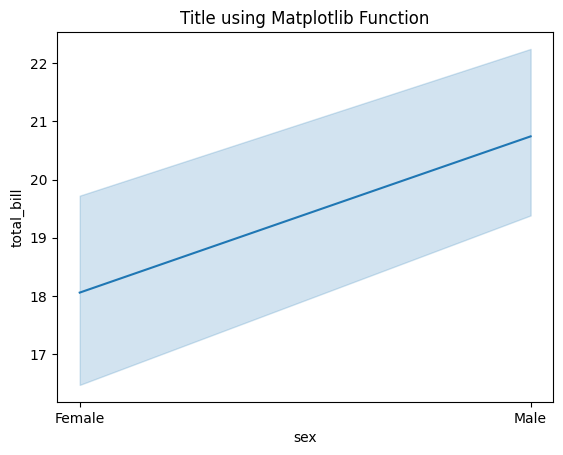

In [71]:
# importing packages
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# draw lineplot
sns.lineplot(x="sex", y="total_bill", data=data)
 
# setting the title using Matplotlib
plt.title('Title using Matplotlib Function')
 
plt.show()

**Scatter Plot**

Scatter plot is plotted using the **scatterplot()** method. This is similar to Matplotlib, but additional argument data is required.

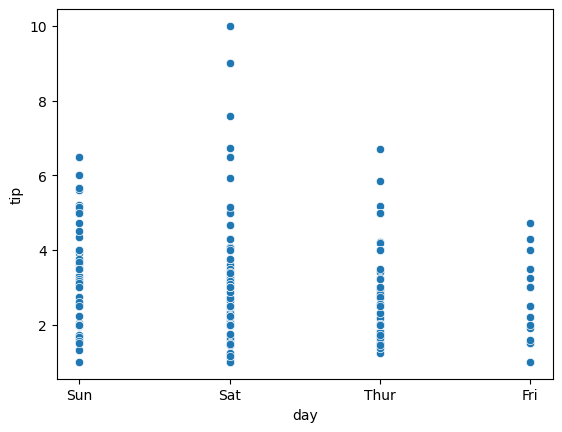

In [72]:
sns.scatterplot(x='day', y='tip', data=data)
plt.show()

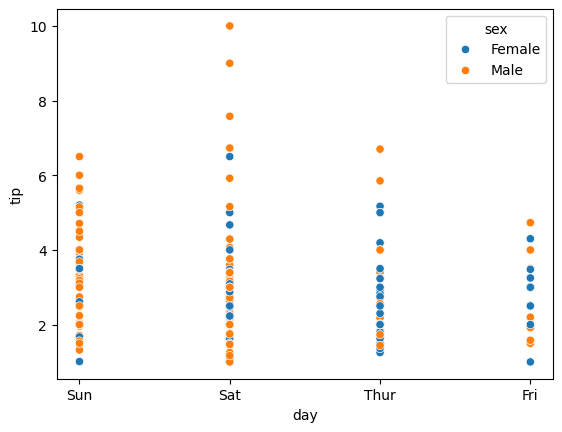

In [73]:
sns.scatterplot(x='day', y='tip', data=data,hue='sex')
plt.show()

**Line Plot**

Line Plot in Seaborn plotted using the **lineplot()** method.  In this, we can pass only the data argument also.

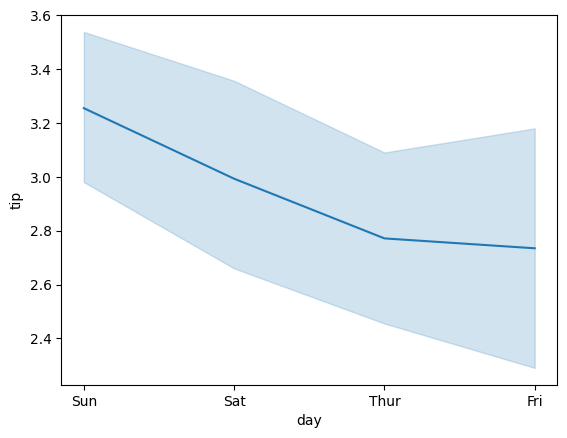

In [74]:
sns.lineplot(x='day', y='tip', data=data)
plt.show()

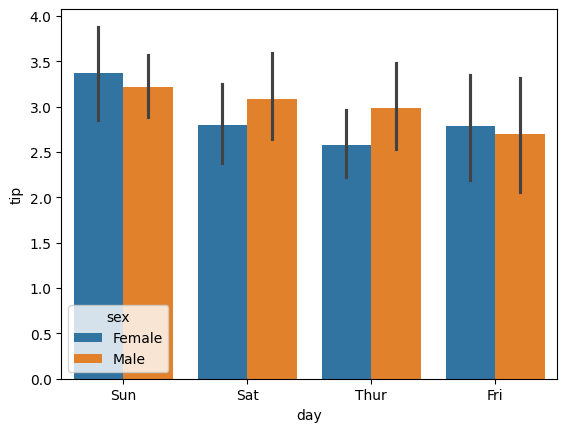

In [75]:
sns.barplot(x='day',y='tip', data=data, hue='sex')
plt.show()

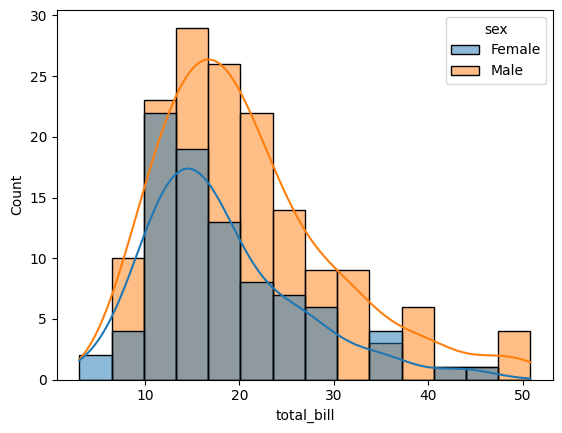

In [76]:
sns.histplot(x='total_bill', data=data, kde=True, hue='sex')
plt.show()

**Bokeh**

Let’s move on to the third library of our list. Bokeh is mainly famous for its interactive charts visualization. Bokeh renders its plots using HTML and JavaScript that uses modern web browsers for presenting elegant, concise construction of novel graphics with high-level interactivity.

In [77]:
# importing the modules
import bokeh
from bokeh.plotting import figure, output_file, show
from bokeh.palettes import magma
import pandas as pd

# instantiating the figure object
graph = figure(title = "Bokeh Scatter Graph")

# reading the database
data = pd.read_csv("tips.csv",delimiter =',')

color = magma(256)

# plotting the graph
graph.scatter(data['total_bill'], data['tip'], color=color)

# displaying the model
show(graph)

C:\Users\Ilyann\AppData\Local\Temp\ipykernel_10424\433626934.py:16: BokehUserWarning:

ColumnDataSource's columns must be of the same length. Current lengths: ('fill_color', 256), ('x', 244), ('y', 244)

C:\Users\Ilyann\AppData\Local\Temp\ipykernel_10424\433626934.py:16: BokehUserWarning:

ColumnDataSource's columns must be of the same length. Current lengths: ('fill_color', 256), ('line_color', 256), ('x', 244), ('y', 244)

C:\Users\Ilyann\AppData\Local\Temp\ipykernel_10424\433626934.py:16: BokehUserWarning:

ColumnDataSource's columns must be of the same length. Current lengths: ('fill_color', 256), ('hatch_color', 256), ('line_color', 256), ('x', 244), ('y', 244)



In [46]:
# importing the modules
from bokeh.plotting import figure, output_file, show
import pandas as pd

# instantiating the figure object
graph = figure(title = "Bokeh Bar Chart")
 
# reading the database
# data = pd.read_csv("tips.csv")
 
# Count of each unique value of
# tip column
df = data['tip'].value_counts()
 
# plotting the graph
graph.line(df, data['tip'])
 
# displaying the model
show(graph)

C:\Users\Ilyann\AppData\Local\Temp\ipykernel_10424\1537739445.py:16: BokehUserWarning:

ColumnDataSource's columns must be of the same length. Current lengths: ('x', 123), ('y', 244)



In [47]:
from bokeh.plotting import figure, output_file, show
import pandas as pd

 
# instantiating the figure object
graph = figure(title = "Bokeh Bar Chart")
 
# reading the database
# data = pd.read_csv("tips.csv")
 
# plotting the graph
graph.vbar(data['total_bill'], top=data['tip'],
           legend_label = "Bill VS Tips", color='green')
 
graph.vbar(data['tip'], top=data['size'],
           legend_label = "Tips VS Size", color='red')
 
graph.legend.click_policy = "hide"

# displaying the model
show(graph)

**Interactive Data Visualization**

One of the key features of Bokeh is to add interaction to the plots. Let’s see various interactions that can be added.

**Interactive Legends**

click_policy property makes the legend interactive. There are two types of interactivity –

- Hiding: Hides the Glyphs.
- Muting: Hiding the glyph makes it vanish completely, on the other hand, muting the glyph just de-emphasizes the glyph based on the parameters.

In [48]:
from bokeh.models import HoverTool

hover = HoverTool(tooltips=[
    ("index", "$index"),
    ("(x, y)", "($x, $y)"),
    ("radius", "@radius"),
    ("fill color", "@fill_color{hex, swatch}"),
    ("foo", "@foo"),
    ("bar", "@bar"),
    ("baz", "@baz{safe}"),
    ("total", "@total{$0,0.00}")
])

graph = figure(title = "Bokeh Bar Chart")
graph.vbar(data["total_bill"], top = data['tip'], legend_label = "Bill VS Tips",color = "green")
graph.vbar(data["tip"], top = data['size'], legend_label = "Tips VS Size",color = "red")
graph.legend.click_policy = "hide"
graph.add_tools(HoverTool())
show(graph)

In [49]:
# Add tooltip (name, field) pairs to the tool. See below for a
# description of possible field values.
from bokeh.models import HoverTool

hover = HoverTool(tooltips=[
    ("index", "$index"),
    ("(x, y)", "($x, $y)"),
    ("radius", "@radius"),
    ("fill color", "@fill_color{hex, swatch}"),
    ("foo", "@foo"),
    ("bar", "@bar"),
    ("baz", "@baz{safe}"),
    ("total", "@total{$0,0.00}")
])

**Adding Widgets**
Bokeh provides GUI features similar to HTML forms like buttons, sliders, checkboxes, etc. These provide an interactive interface to the plot that allows changing the parameters of the plot, modifying plot data, etc. Let’s see how to use and add some commonly used widgets. 

**Buttons:** This widget adds a simple button widget to the plot. We have to pass a custom JavaScript function to the CustomJS() method of the models class.

**CheckboxGroup:** Adds a standard check box to the plot. Similarly to buttons we have to pass the custom JavaScript function to the CustomJS() method of the models class.

**RadioGroup:** Adds a simple radio button and accepts a custom JavaScript function.

In [50]:
from bokeh.io import show
from bokeh.models import Button, SetValue

button = Button(label="Foo", button_type="primary")
callback = SetValue(obj=button, attr="label", value="Bar")
button.js_on_event("button_click", callback)

show(button)

In [51]:
from bokeh.io import show
from bokeh.models import Button, CustomJS

button = Button(label="Foo", button_type="primary")

callback = CustomJS(code="""
    // Get the button element by its id
    var button = document.getElementById('%s');
    
    // Change the label when the button is clicked
    button.textContent = "Bar";
""" % button.id)

button.js_on_event("button_click", callback)

show(button)
 

In [52]:


import plotly.express as px
import pandas as pd
 
# reading the database
# data = pd.read_csv("tips.csv")
 
# plotting the scatter chart
fig = px.scatter(data, x="day", y="tip", color='sex')
 
# showing the plot
fig.show()

In [53]:
# Lineplot
import plotly.express as px
import pandas as pd
  
# plotting the line chart
fig = px.line(data, y='tip', color='sex')
 
# showing the plot
fig.show()

In [54]:
# plotting the bar chart
fig = px.bar(data, x='day', y='tip', color='sex')
 
# showing the plot
fig.show()

In [55]:
# plotting the histogram chart
fig = px.histogram(data, x='total_bill', color='sex')
 
# showing the plot
fig.show()

**Adding interaction**

Just like Bokeh, plotly also provides various interactions. Let’s discuss a few of them.

**Creating Dropdown Menu:** A drop-down menu is a part of the menu-button which is displayed on a screen all the time. Every menu button is associated with a Menu widget that can display the choices for that menu button when clicked on it. In plotly, there are 4 possible methods to modify the charts by using updatemenu method.

- **restyle:** modify data or data attributes
- **relayout:** modify layout attributes
- **update:** modify data and layout attributes
- **animate:** start or pause an animation

In [56]:
import plotly.graph_objects as px
import pandas as pd
 
# reading the database
# data = pd.read_csv("tips.csv")
 
 
plot = px.Figure(data=[px.Scatter(
    x=data['day'],
    y=data['tip'],
    mode='markers',)
])
 
# Add dropdown
plot.update_layout(
    updatemenus=[
        dict(
            buttons=list([
                dict(
                    args=["type", "scatter"],
                    label="Scatter Plot",
                    method="restyle"
                ),
                dict(
                    args=["type", "bar"],
                    label="Bar Chart",
                    method="restyle"
                )
            ]),
            direction="down",
        ),
    ]
)
 
plot.show()

In [57]:
import plotly.graph_objects as px
import pandas as pd
 
# reading the database
# data = pd.read_csv("tips.csv")
 
 
plot = px.Figure(data=[px.Scatter(
    x=data['day'],
    y=data['tip'],
    mode='markers',)
])
 
# Add OPTIONS SIDEBYSIDE
plot.update_layout(
    updatemenus=[
        dict(
            type="buttons",
            direction="left",
            buttons=list([
                dict(
                    args=["type", "scatter"],
                    label="Scatter Plot",
                    method="restyle"
                ),
                dict(
                    args=["type", "bar"],
                    label="Bar Chart",
                    method="restyle"
                )
            ]),
        ),
    ]
)
 
plot.show()

**Creating Sliders and Selectors:**

In plotly, the range slider is a custom range-type input control. It allows selecting a value or a range of values between a specified minimum and maximum range. And the range selector is a tool for selecting ranges to display within the chart. It provides buttons to select pre-configured ranges in the chart. It also provides input boxes where the minimum and maximum dates can be manually input

In [58]:
import plotly.graph_objects as px
import pandas as pd
 
# reading the database
# data = pd.read_csv("tips.csv")
 
plot = px.Figure(data=[px.Scatter(
    y=data['tip'],
    mode='lines',)
])
 
plot.update_layout(
    xaxis=dict(
        rangeselector=dict(
            buttons=list([
                dict(count=1,
                    step="day",
                    stepmode="backward"),
            ])
        ),
        rangeslider=dict(
            visible=True
        ),
    )
)
 
plot.show()

In [59]:
import altair as alt
from vega_datasets import data

cars = data.cars()
cars.head()

,Name,Miles_per_Gallon,Cylinders,Displacement,Horsepower,Weight_in_lbs,Acceleration,Year,Origin
0,chevrolet chevelle malibu,18.0,8,307.0,130.0,3504,12.0,1970-01-01,USA
1,buick skylark 320,15.0,8,350.0,165.0,3693,11.5,1970-01-01,USA
2,plymouth satellite,18.0,8,318.0,150.0,3436,11.0,1970-01-01,USA
3,amc rebel sst,16.0,8,304.0,150.0,3433,12.0,1970-01-01,USA
4,ford torino,17.0,8,302.0,140.0,3449,10.5,1970-01-01,USA


In [60]:

cars = data.cars.url

alt.Chart(cars).mark_circle().encode(
    x='Horsepower:Q',
    y='Miles_per_Gallon:Q',
    color='Origin:N'
)

alt.Chart(...)

In [61]:
op_var2 = 0.1

alt.Chart(cars).mark_circle(opacity=op_var2).encode(
    x='Horsepower:Q',
    y='Miles_per_Gallon:Q',
    color='Origin:N'
)

alt.Chart(...)

Q → Quantitative → Numbers (continuous scales).  
N → Nominal → Categories (no order).  
O → Ordinal → Ordered categories.  
T → Temporal → Dates/times.

In [62]:
import altair as alt
from vega_datasets import data

# Load the example 'cars' dataset
cars = data.cars()


# Brush along the x-axis
brush = alt.selection_interval(encodings=['x'], name='brush')
# Optional: click legend to include/exclude categories
origin_sel = alt.selection_point(fields=['Origin'], bind='legend', name='origin')

# Base chart styling & shared encodings
base = alt.Chart(cars).mark_point().encode(
    color=alt.condition(origin_sel & brush, 'Origin:N', alt.value('lightgray')),
    tooltip=[
        'Name:N', 'Origin:N',
        'Horsepower:Q', 'Miles_per_Gallon:Q', 'Acceleration:Q', 'Year:T'
    ]
).properties(width=280, height=260)

# Chart 1: Horsepower vs Acceleration
chart1 = base.encode(
    x=alt.X('Acceleration:Q', title='Acceleration'),
    y=alt.Y('Horsepower:Q', title='Horsepower')
).add_params(brush, origin_sel)

# Chart 2: MPG vs MPG (kept to match your original intent)
# (Consider changing x to a different quantitative field for more insight,
# e.g., x='Weight_in_lbs:Q' or x='Displacement:Q'.)
chart2 = base.encode(
    x=alt.X('Miles_per_Gallon:Q', title='Miles per Gallon'),
    y=alt.Y('Miles_per_Gallon:Q', title='Miles per Gallon')
).add_params(brush, origin_sel)

# Side-by-side layout
chart1 | chart2

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:

You passed a `<class 'narwhals.stable.v1.DataFrame'>` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(df)`, did you mean `is_pandas_dataframe(df.to_native())`?



alt.HConcatChart(...)

**Simple Interactions**

One of the nicest features of Altair is the grammar of interaction that it provides. The simplest kind of interaction is the ability to pan and zoom along charts; Altair contains a shortcut to enable this via the **interactive()** method:

In [63]:
alt.Chart(cars).mark_point().encode(
    x='Miles_per_Gallon',
    y='Horsepower'
).interactive()

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:

You passed a `<class 'narwhals.stable.v1.DataFrame'>` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(df)`, did you mean `is_pandas_dataframe(df.to_native())`?

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:

You passed a `<class 'narwhals.stable.v1.DataFrame'>` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(df)`, did you mean `is_pandas_dataframe(df.to_native())`?

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:

You passed a `<class 'narwhals.stable.v1.DataFrame'>` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(df)`, did you mean `is_pandas_dataframe(df.to_native())`?



alt.Chart(...)

**A Third Dimension: Color**

A 2D plot allows us to encode two dimensions of the data. Let’s look at using color to encode a third:

In [64]:
alt.Chart(cars).mark_point().encode(
    x='Miles_per_Gallon',
    y='Horsepower',
    color='Origin'
)

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:

You passed a `<class 'narwhals.stable.v1.DataFrame'>` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(df)`, did you mean `is_pandas_dataframe(df.to_native())`?

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:

You passed a `<class 'narwhals.stable.v1.DataFrame'>` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(df)`, did you mean `is_pandas_dataframe(df.to_native())`?

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:

You passed a `<class 'narwhals.stable.v1.DataFrame'>` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(df)`, did you mean `is_pandas_dataframe(df.to_native())`?

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:


alt.Chart(...)

In [65]:
alt.Chart(cars).mark_point().encode(
    x='Miles_per_Gallon',
    y='Horsepower',
    color='Acceleration'
)

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:

You passed a `<class 'narwhals.stable.v1.DataFrame'>` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(df)`, did you mean `is_pandas_dataframe(df.to_native())`?

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:

You passed a `<class 'narwhals.stable.v1.DataFrame'>` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(df)`, did you mean `is_pandas_dataframe(df.to_native())`?

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:

You passed a `<class 'narwhals.stable.v1.DataFrame'>` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(df)`, did you mean `is_pandas_dataframe(df.to_native())`?

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:


alt.Chart(...)

In [66]:
alt.Chart(cars).mark_point().encode(
    x='Miles_per_Gallon',
    y='Horsepower',
    color='Cylinders'
)

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:

You passed a `<class 'narwhals.stable.v1.DataFrame'>` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(df)`, did you mean `is_pandas_dataframe(df.to_native())`?

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:

You passed a `<class 'narwhals.stable.v1.DataFrame'>` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(df)`, did you mean `is_pandas_dataframe(df.to_native())`?

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:

You passed a `<class 'narwhals.stable.v1.DataFrame'>` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(df)`, did you mean `is_pandas_dataframe(df.to_native())`?

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:


alt.Chart(...)

In [67]:
alt.Chart(cars).mark_point().encode(
    x='Miles_per_Gallon',
    y='Horsepower',
    color='Cylinders:O'
)

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:

You passed a `<class 'narwhals.stable.v1.DataFrame'>` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(df)`, did you mean `is_pandas_dataframe(df.to_native())`?

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:

You passed a `<class 'narwhals.stable.v1.DataFrame'>` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(df)`, did you mean `is_pandas_dataframe(df.to_native())`?

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:

You passed a `<class 'narwhals.stable.v1.DataFrame'>` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(df)`, did you mean `is_pandas_dataframe(df.to_native())`?



alt.Chart(...)

In [68]:
alt.Chart(cars).mark_bar().encode(
    x=alt.X('Miles_per_Gallon', bin=True),
    y='count()'
)

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:

You passed a `<class 'narwhals.stable.v1.DataFrame'>` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(df)`, did you mean `is_pandas_dataframe(df.to_native())`?

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:

You passed a `<class 'narwhals.stable.v1.DataFrame'>` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(df)`, did you mean `is_pandas_dataframe(df.to_native())`?



alt.Chart(...)

In [69]:
alt.Chart(cars).mark_bar().encode(
    x=alt.X('Miles_per_Gallon', bin=alt.Bin(maxbins=30)),
    y='count()'
)

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:

You passed a `<class 'narwhals.stable.v1.DataFrame'>` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(df)`, did you mean `is_pandas_dataframe(df.to_native())`?

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:

You passed a `<class 'narwhals.stable.v1.DataFrame'>` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(df)`, did you mean `is_pandas_dataframe(df.to_native())`?



alt.Chart(...)

If we want more control over the bins, we can use **alt.Bin** to adjust bin parameters

When you want to bin a quantitative variable (turn continuous values into grouped ranges), Altair can do this automatically. But if you want more control over:  bin size (step between bins)  number of bins  start / end of bins

In [78]:
alt.Chart(cars).mark_bar().encode(
    x=alt.X('Miles_per_Gallon', bin=alt.Bin(maxbins=30)),
    y='count()',
    color='Origin'
)

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:

You passed a `<class 'narwhals.stable.v1.DataFrame'>` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(df)`, did you mean `is_pandas_dataframe(df.to_native())`?

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:

You passed a `<class 'narwhals.stable.v1.DataFrame'>` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(df)`, did you mean `is_pandas_dataframe(df.to_native())`?

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:

You passed a `<class 'narwhals.stable.v1.DataFrame'>` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(df)`, did you mean `is_pandas_dataframe(df.to_native())`?



alt.Chart(...)

In [79]:
alt.Chart(cars).mark_bar().encode(
    x=alt.X('Miles_per_Gallon', bin=alt.Bin(maxbins=30)),
    y='count()',
    color='Origin',
    column='Origin'
)

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:

You passed a `<class 'narwhals.stable.v1.DataFrame'>` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(df)`, did you mean `is_pandas_dataframe(df.to_native())`?

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:

You passed a `<class 'narwhals.stable.v1.DataFrame'>` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(df)`, did you mean `is_pandas_dataframe(df.to_native())`?

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:

You passed a `<class 'narwhals.stable.v1.DataFrame'>` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(df)`, did you mean `is_pandas_dataframe(df.to_native())`?

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:


alt.Chart(...)

In [80]:
alt.Chart(cars).mark_rect().encode(
    x=alt.X('Miles_per_Gallon', bin=True),
    y=alt.Y('Horsepower', bin=True),
    color='count()'
)

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:

You passed a `<class 'narwhals.stable.v1.DataFrame'>` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(df)`, did you mean `is_pandas_dataframe(df.to_native())`?

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:

You passed a `<class 'narwhals.stable.v1.DataFrame'>` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(df)`, did you mean `is_pandas_dataframe(df.to_native())`?

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:

You passed a `<class 'narwhals.stable.v1.DataFrame'>` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(df)`, did you mean `is_pandas_dataframe(df.to_native())`?



alt.Chart(...)

**Time-Series & Layering**

So far we’ve been ignoring the date column, but it’s interesting to see the trends with time of, for example, miles per gallon:

In [81]:
alt.Chart(cars).mark_point().encode(
    x='Year',
    y='Miles_per_Gallon'
)

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:

You passed a `<class 'narwhals.stable.v1.DataFrame'>` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(df)`, did you mean `is_pandas_dataframe(df.to_native())`?

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:

You passed a `<class 'narwhals.stable.v1.DataFrame'>` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(df)`, did you mean `is_pandas_dataframe(df.to_native())`?

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:

You passed a `<class 'narwhals.stable.v1.DataFrame'>` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(df)`, did you mean `is_pandas_dataframe(df.to_native())`?



alt.Chart(...)

In [82]:
alt.Chart(cars).mark_line().encode(
    x='Year',
    y='mean(Miles_per_Gallon)',
)

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:

You passed a `<class 'narwhals.stable.v1.DataFrame'>` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(df)`, did you mean `is_pandas_dataframe(df.to_native())`?

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:

You passed a `<class 'narwhals.stable.v1.DataFrame'>` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(df)`, did you mean `is_pandas_dataframe(df.to_native())`?

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:

You passed a `<class 'narwhals.stable.v1.DataFrame'>` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(df)`, did you mean `is_pandas_dataframe(df.to_native())`?



alt.Chart(...)

In [83]:
alt.Chart(cars).mark_area().encode(
    x='Year',
    y='ci0(Miles_per_Gallon)',
    y2='ci1(Miles_per_Gallon)'
)

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:

You passed a `<class 'narwhals.stable.v1.DataFrame'>` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(df)`, did you mean `is_pandas_dataframe(df.to_native())`?

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:

You passed a `<class 'narwhals.stable.v1.DataFrame'>` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(df)`, did you mean `is_pandas_dataframe(df.to_native())`?

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:

You passed a `<class 'narwhals.stable.v1.DataFrame'>` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(df)`, did you mean `is_pandas_dataframe(df.to_native())`?

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:


alt.Chart(...)

In [84]:
alt.Chart(cars).mark_area(opacity=0.3).encode(
    x=alt.X('Year', timeUnit='year'),
    y=alt.Y('ci0(Miles_per_Gallon)', axis=alt.Axis(title='Miles per Gallon')),
    y2='ci1(Miles_per_Gallon)',
    color='Origin'
).properties(
    width=800
)

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:

You passed a `<class 'narwhals.stable.v1.DataFrame'>` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(df)`, did you mean `is_pandas_dataframe(df.to_native())`?

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:

You passed a `<class 'narwhals.stable.v1.DataFrame'>` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(df)`, did you mean `is_pandas_dataframe(df.to_native())`?

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:

You passed a `<class 'narwhals.stable.v1.DataFrame'>` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(df)`, did you mean `is_pandas_dataframe(df.to_native())`?

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:


alt.Chart(...)

In [85]:
spread = alt.Chart(cars).mark_area(opacity=0.3).encode(
    x=alt.X('Year', timeUnit='year'),
    y=alt.Y('ci0(Miles_per_Gallon)', axis=alt.Axis(title='Miles per Gallon')),
    y2='ci1(Miles_per_Gallon)',
    color='Origin'
).properties(
    width=800
)

lines = alt.Chart(cars).mark_line().encode(
    x=alt.X('Year', timeUnit='year'),
    y='mean(Miles_per_Gallon)',
    color='Origin'
).properties(
    width=800
)

spread + lines

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:

You passed a `<class 'narwhals.stable.v1.DataFrame'>` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(df)`, did you mean `is_pandas_dataframe(df.to_native())`?

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:

You passed a `<class 'narwhals.stable.v1.DataFrame'>` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(df)`, did you mean `is_pandas_dataframe(df.to_native())`?

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:

You passed a `<class 'narwhals.stable.v1.DataFrame'>` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(df)`, did you mean `is_pandas_dataframe(df.to_native())`?

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:


alt.LayerChart(...)

In [86]:
interval = alt.selection_interval()

base = alt.Chart(cars).mark_point().encode(
    y='Horsepower',
    color=alt.condition(interval, 'Origin', alt.value('lightgray')),
    tooltip='Name'
).add_selection(
    interval
)

hist = alt.Chart(cars).mark_bar().encode(
    x='count()',
    y='Origin',
    color='Origin'
).properties(
    width=800,
    height=80
).transform_filter(
    interval
)

scatter = base.encode(x='Miles_per_Gallon') | base.encode(x='Acceleration')

scatter & hist

C:\Users\Ilyann\AppData\Local\Temp\ipykernel_10424\1046255109.py:7: AltairDeprecationWarning:

Deprecated in `altair=5.0.0`. Use add_params instead.

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:

You passed a `<class 'narwhals.stable.v1.DataFrame'>` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(df)`, did you mean `is_pandas_dataframe(df.to_native())`?

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:

You passed a `<class 'narwhals.stable.v1.DataFrame'>` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(df)`, did you mean `is_pandas_dataframe(df.to_native())`?

c:\Users\Ilyann\AppData\Local\Programs\Python\Python310\lib\site-packages\altair\utils\data.py:71: UserWarning:

You passed a `<class 'narwhals.stable.v1.DataFrame'>` to `is_pandas_dataframe`.

Hint: Instead of e.g. `is_pandas_dataframe(df)`, did you mean `i

alt.VConcatChart(...)